# Neural Networks Project - Course 2 (Machine Learning Specialization)

**Name**: *Marah Akram Abou Abdo*

**Field**: *Machine Learning / Deep Learning*

**Project Purpose:**
*This project is created to apply and understand the core concepts of neural networks including data preprocessing, model building, training, evaluation, and optimization.*

# Introduction
**This project focuses on building a neural network model to classify breast cancer tumors as either malignant or benign. The main goal is to apply machine learning and deep learning techniques on real medical data to predict tumor types based on different features. The project includes data preprocessing, model building, training, evaluation, and optimization to improve performance and achieve accurate predictions on unseen data.**

## 1. Import Required Libraries

In [23]:
# Data analysis and visualization libraries
import pandas as pd               
import matplotlib.pyplot as plt 
import seaborn as sns   
import numpy as np

# Scikit-learn tools for dataset, preprocessing, splitting, and evaluation
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score , precision_score , recall_score, f1_score, confusion_matrix, roc_curve, auc 

# TensorFlow and Keras for building neural network models
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential,callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout 

# Display plots inside notebook
%matplotlib inline

# Set plot style
sns.set_style('whitegrid')

# Show TensorFlow version
print("TensorFlow version:",tf.__version__)

TensorFlow version: 2.21.0


## 2. Load Dataset

In [24]:
# Load Breast Cancer dataset from sklearn
data = load_breast_cancer()

# Split dataset into features (X) and labels (y)
X = data.data
y = data.target

# Show dataset shapes (features and target)
print(" X shape ",X.shape)
print(" Y shape ",y.shape)

 X shape  (569, 30)
 Y shape  (569,)


## 3. Exploratory Data Analysis 

In [25]:
feature_names = data.feature_names
target_names = data.target_names
print("Frist 5 features names:\n",feature_names[:5])
print("Target classes:",target_names)

Frist 5 features names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']
Target classes: ['malignant' 'benign']


In [26]:
# Show how many samples exist in each class (0 = malignant, 1 = benign)
print("Class distribution: \n",pd.Series(y).value_counts()) 

Class distribution: 
 1    357
0    212
Name: count, dtype: int64


In [27]:
# Create a DataFrame from features and add target column
df = pd.DataFrame(X, columns = feature_names)
df['target'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [28]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [29]:
# Split dataset into training and testing sets (80% train, 20% test) while keeping class distribution balanced
X_train, X_test, y_train, y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42, stratify = y)
print("Train size:", X_train.shape)
print("Test size:",X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


## 4. Cross Validation

In [37]:
# 5-Fold Stratified Cross Validation setup
Kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []
fold_no =1

for train, val in Kfold.split(X,y):
    # Split data into training and validation for each fold
    x_train_fold, x_val_fold = X[train], X[val]
    y_train_fold, y_val_fold = y[train], y[val]
    
    # Standardize features
    scaler = StandardScaler()
    x_train_fold = scaler.fit_transform(x_train_fold)
    x_val_fold = scaler.transform(x_val_fold)

    # Build neural network model
    model_fold = Sequential([
    Dense(17, activation= 'relu', input_shape=(x_train_fold.shape[1],)),
    Dense(8, activation ='relu'),
    Dense(1, activation ='sigmoid')
    ])

    model_fold.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
    model_fold.fit(x_train_fold,y_train_fold,epochs=30,batch_size=16,verbose=0)
  
    # Evaluate model on validation fold
    loss, acc =model_fold.evaluate(x_val_fold,y_val_fold,verbose=0)

    
    # Store accuracy
    cv_accuracies.append(acc)
    print(f"Fold {fold_no} - Accuracy:{acc:.4f}")
    fold_no +=1
    
# Show average performance across all folds
print(f"\nMean CV Accuracy: {np.mean(cv_accuracies):.4f} (+/- {np.std(cv_accuracies):.4f})")    

C:\Users\Eng.Marah Abou Abdo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 1 - Accuracy:0.9737


C:\Users\Eng.Marah Abou Abdo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 2 - Accuracy:0.9737


C:\Users\Eng.Marah Abou Abdo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 3 - Accuracy:0.9737


C:\Users\Eng.Marah Abou Abdo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 4 - Accuracy:0.9912


C:\Users\Eng.Marah Abou Abdo\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Fold 5 - Accuracy:0.9912

Mean CV Accuracy: 0.9807 (+/- 0.0086)


## 5. Data Preprocessing (Feature Scaling using StandardScaler)

In [38]:
# Standardize features (make mean = 0 and standard deviation = 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(X_train[:5])

[[-1.07200079e+00 -6.58424598e-01 -1.08808010e+00 -9.39273639e-01
  -1.35939882e-01 -1.00871795e+00 -9.68358632e-01 -1.10203235e+00
   2.81062120e-01 -1.13231479e-01 -7.04860874e-01 -4.40938351e-01
  -7.43948977e-01 -6.29804931e-01  7.48061001e-04 -9.91572979e-01
  -6.93759567e-01 -9.83284458e-01 -5.91579010e-01 -4.28972052e-01
  -1.03409427e+00 -6.23497432e-01 -1.07077336e+00 -8.76534437e-01
  -1.69982346e-01 -1.03883630e+00 -1.07899452e+00 -1.35052668e+00
  -3.52658049e-01 -5.41380026e-01]
 [ 1.74874285e+00  6.65017334e-02  1.75115682e+00  1.74555856e+00
   1.27446827e+00  8.42288215e-01  1.51985232e+00  1.99466430e+00
  -2.93045055e-01 -3.20179716e-01  1.27567198e-01 -3.81382677e-01
   9.40746962e-02  3.17524379e-01  6.39656015e-01  8.73892616e-02
   7.08450758e-01  1.18215034e+00  4.26212305e-01  7.47970186e-02
   1.22834212e+00 -9.28334970e-02  1.18746742e+00  1.10438613e+00
   1.51700092e+00  2.49654896e-01  1.17859444e+00  1.54991557e+00
   1.91077868e-01 -1.73738602e-01]
 [-9.7

## 6. Model Building (Neural Network Architecture)

In [43]:
# Build a simple neural network model for binary classification
model = Sequential([
    Dense(15, activation = 'relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

# Compile model: define optimizer, loss function, and evaluation metric
model.compile(optimizer = 'adam', loss = 'binary_crossentropy',metrics = ['accuracy'])
model.summary()


Model: "sequential_50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_151 (Dense)               │ (None, 15)             │           465 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 8)              │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_153 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 602 (2.35 KB)

 Trainable params: 602 (2.35 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
# Train model and store training history
history = model.fit(X_train, y_train, epochs = 50, batch_size = 16, validation_split = 0.2,verbose=1)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7005 - loss: 0.5652 - val_accuracy: 0.8022 - val_loss: 0.4840
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8242 - loss: 0.3902 - val_accuracy: 0.8791 - val_loss: 0.3684
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8984 - loss: 0.2982 - val_accuracy: 0.9121 - val_loss: 0.2936
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9176 - loss: 0.2390 - val_accuracy: 0.9231 - val_loss: 0.2428
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9313 - loss: 0.1972 - val_accuracy: 0.9341 - val_loss: 0.2083
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9396 - loss: 0.1679 - val_accuracy: 0.9341 - val_loss: 0.1819
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9451 - loss: 0.1472 - val_accuracy: 0.9341 - val_loss: 0.1618
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9533 - loss: 0.1308 - val_accuracy: 0.9341 - val_loss

## 7. Model Evaluation (Performance Metrics on Test Data)

In [45]:
# Evaluate model on test data and calculate predictions
test_loss, test_acc = model.evaluate(X_test, y_test, verbose = 0)
print(f"Test Accuracy :{test_acc:.4f}")

# Predict probabilities and convert them to binary classes (0/1)
y_pred_probablity = model.predict(X_test)
y_pred = (y_pred_probablity > 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Test Accuracy :0.9649
2/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step WARNING:tensorflow:5 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000222EB8B59E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
Accuracy: 0.9649
Precision: 0.9857
Recall: 0.9583
F1-Score: 0.9718


## 8. Visualization of Model Performance (Confusion Matrix & ROC Curve)

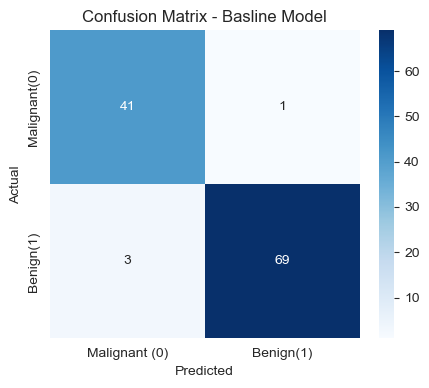

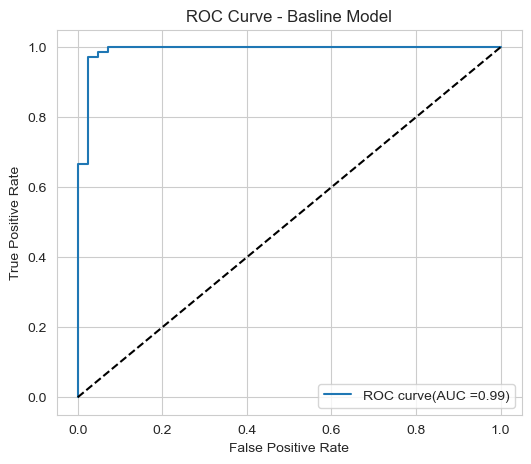

In [47]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot =True, fmt='d',cmap='Blues',
            xticklabels=['Malignant (0)','Benign(1)'],
            yticklabels=['Malignant(0)','Benign(1)'])


plt.title('Confusion Matrix - Basline Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

fpr,tpr,_ = roc_curve(y_test,y_pred_probablity)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr,tpr, label =f'ROC curve(AUC ={roc_auc:.2f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Basline Model')
plt.legend()
plt.show()


## 9. Training Performance Visualization (Loss & Accuracy Curves)

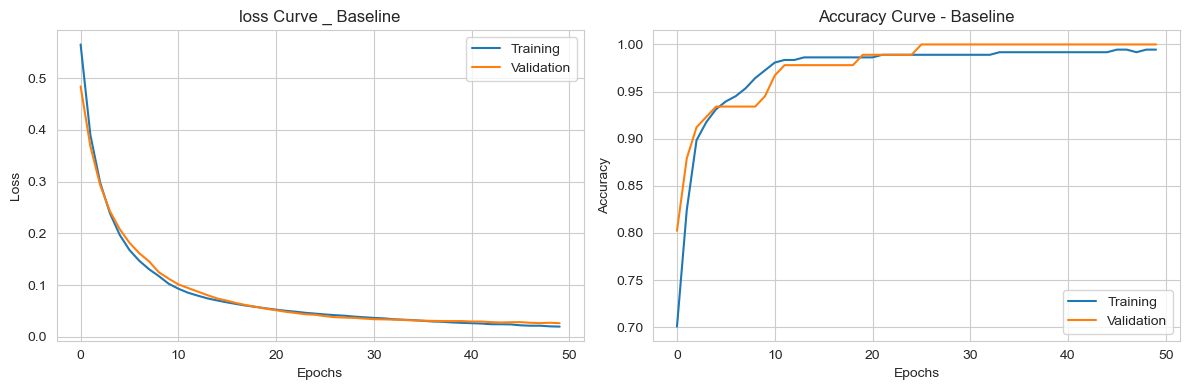

In [50]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label = 'Training')
plt.plot(history.history['val_loss'],label='Validation')
plt.title('loss Curve _ Baseline')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label = 'Training')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.title('Accuracy Curve - Baseline')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 10. Model Optimization (Improved Architecture with Dropout & Early Stopping)

In [51]:
# Optimized neural network model with Dropout to reduce overfitting
model_opt = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(16,activation='relu'),
    Dropout(0.2),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_opt.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',metrics = ['accuracy'])
model_opt.summary()

# Early stopping to stop training when validation loss stops improving
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=15,restore_best_weights=True)

history_opt = model_opt.fit(
    X_train, y_train,
    epochs = 100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_158 (Dense)               │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_159 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_160 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_161 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,665 (6.50 KB)

 Trainable params: 1,665 (6.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.7335 - loss: 0.5592 - val_accuracy: 0.9121 - val_loss: 0.4404
Epoch 2/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9121 - loss: 0.3337 - val_accuracy: 0.9231 - val_loss: 0.2490
Epoch 3/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9286 - loss: 0.2179 - val_accuracy: 0.9451 - val_loss: 0.1532
Epoch 4/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9423 - loss: 0.1605 - val_accuracy: 0.9560 - val_loss: 0.1141
Epoch 5/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1322 - val_accuracy: 0.9780 - val_loss: 0.0895
Epoch 6/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9753 - loss: 0.0980 - val_accuracy: 0.9780 - val_loss: 0.0724
Epoch 7/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9698 - loss: 0.0925 - val_accuracy: 0.9780 - val_loss: 0.0684
Epoch 8/100
46/46 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9753 - loss: 0.0983 - val_accuracy: 0.9780 

In [60]:
# Evaluate optimized model on test data
test_loss_opt, test_acc_opt = model_opt.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (optimized):{test_acc_opt:.4f}")

y_pred_proba_opt = model_opt.predict(X_test)
y_pred_opt = (y_pred_proba_opt > 0.5).astype(int)

acc_opt = accuracy_score(y_test, y_pred_opt)
prec_opt = precision_score(y_test, y_pred_opt)
rec_opt = recall_score(y_test, y_pred_opt)
f1_opt = f1_score(y_test,y_pred_opt)
print(f"Accuracy: {acc_opt:.4f}, Precision:{prec_opt:.4f}, Recall:{rec_opt:.4f}, F1: {f1_opt:.4f}")

Test Accuracy (optimized):0.9649
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Accuracy: 0.9649, Precision:0.9857, Recall:0.9583, F1: 0.9718


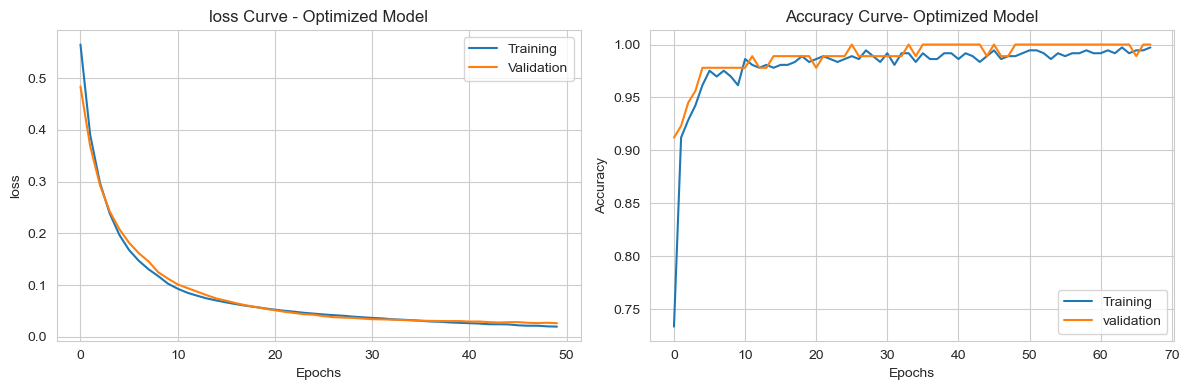

In [62]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'],label='Training')
plt.plot(history.history['val_loss'],label='Validation')
plt.title('loss Curve - Optimized Model')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_opt.history['accuracy'],label='Training')
plt.plot(history_opt.history['val_accuracy'], label='validation')
plt.title('Accuracy Curve- Optimized Model')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## 11. Prediction on New Data

In [63]:
new_sample = X_test[:5]
true_labels = y_test[:5]

predictions = model_opt.predict(new_sample)
predicted_classes = (predictions > 0.5).astype(int)

print("Predictions on new unseen data: ")
for i, (prob, pred, true) in enumerate(zip(predictions, predicted_classes, true_labels)):
    print(f"Sample {i+1}: Probability benign = {prob[0]:.4f} -> Predicted: {'Benign' if pred[0]==1 else 'Malignant'} (True: {'Benign' if true == 1 else 'Malignant'})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
Predictions on new unseen data: 
Sample 1: Probability benign = 0.0000 -> Predicted: Malignant (True: Malignant)
Sample 2: Probability benign = 1.0000 -> Predicted: Benign (True: Benign)
Sample 3: Probability benign = 0.0000 -> Predicted: Malignant (True: Malignant)
Sample 4: Probability benign = 0.0946 -> Predicted: Malignant (True: Benign)
Sample 5: Probability benign = 0.0000 -> Predicted: Malignant (True: Malignant)


## 12. Save Trained Model

In [68]:
model_opt.save('Deep_Learning_Model_for_Breast_Cancer_Classification.keras')
print("Model saved successfully as 'Deep_Learning_Model_for_Breast_Cancer_Classification.keras' ")

Model saved successfully as 'Deep_Learning_Model_for_Breast_Cancer_Classification.keras' 


In [70]:
import os
print(os.getcwd())

C:\Users\Eng.Marah Abou Abdo\Neural_Network_Project_2026_khalid
